
# Nigerian Social Media Sentiment Analysis — Full Pipeline (Kaggle)

This notebook implements the methodology described in **Chapter 3 (Research
Methodology)** of *Sentiment Analysis of Nigerian Public Issues on Social Media*:

1. Data loading (annotated tweet corpus)
2. Text cleaning & normalisation (Nigerian social-media aware)
3. Tokenisation, stop-word removal (negation-aware), lemmatisation
4. Feature extraction — Bag-of-Words (BoW) and TF-IDF (uni+bi-grams)
5. Train / validation / test split (70/10/20, stratified)
6. Class-imbalance handling with SMOTE
7. Model training + 5-fold GridSearchCV — Multinomial Naive Bayes, Linear SVM,
   Logistic Regression, Random Forest
8. Evaluation — Accuracy, macro Precision/Recall/F1, Confusion Matrix, AUC-ROC (OvR)
9. Model comparison and selection of the best classifier
10. Exporting the winning model + vectoriser as artifacts for the Streamlit app

**How to use on Kaggle:**
- Create a Kaggle Dataset containing your annotated CSV (columns: `text`, `label`,
  optionally `issue_domain`) and add it to this notebook under *Add Data*.
- Set `DATA_PATH` in the config cell below to that file's path
  (e.g. `/kaggle/input/nigeria-sentiment/annotated_tweets.csv`).
- If you don't yet have an annotated dataset, a synthetic-but-realistic sample
  is generated automatically so the whole pipeline still runs end-to-end —
  replace it with your real 5,000-tweet annotated corpus for real results.
- Turn on Internet in Notebook Settings if you want to run the optional Tweepy
  collection cell (Section 1B) — it is skipped by default.


## 0. Environment Setup

In [1]:

# Kaggle notebooks already ship pandas/numpy/scikit-learn/matplotlib/seaborn.
# We only need to add a few extra libraries used by the methodology.
import sys, subprocess

def pip_install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip_install([
    "emoji",
    "imbalanced-learn",
    "nltk",
    "joblib",
])
print("Packages installed.")


Packages installed.


In [2]:

import re
import os
import json
import string
import warnings
import joblib
import emoji
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("punkt", quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Environment ready.")


Environment ready.


## 1. Configuration

In [4]:

# ----- EDIT THIS -----------------------------------------------------
# DATASET_SOURCE controls where the corpus comes from:
#   "naijasenti"  -> download the real, published NaijaSenti Twitter corpus
#                    (Muhammad et al., 2022) from Hugging Face. DEFAULT.
#   "custom_csv"  -> use your own annotated CSV at DATA_PATH
#                    (columns: 'text', 'label', optionally 'issue_domain')
#   "synthetic"   -> generate a tiny template-based sample, only useful for
#                    smoke-testing this notebook when you have no internet
#                    access and no CSV yet (NOT real data — do not report
#                    results trained on it).
DATASET_SOURCE = "naijasenti"

# Only used when DATASET_SOURCE == "custom_csv"
DATA_PATH = "/kaggle/input/nigeria-sentiment/annotated_tweets.csv"

# NaijaSenti language configs to pull from Hugging Face. 'pcm' = Nigerian
# Pidgin, which is the closest match to general English-mixed Nigerian
# social-media discourse. You can add "hau", "ibo", "yor" too, but the
# ISSUE_KEYWORDS domain-tagging below is written in English/Pidgin, so
# tweets in Hausa/Igbo/Yoruba won't be tagged into an issue domain unless
# you extend the keyword lists with translated terms.
NAIJASENTI_LANGS = ["pcm"]

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)
# ----------------------------------------------------------------------



## 1A. Load the Real Dataset — NaijaSenti (Hugging Face)

**Where this data comes from:** [NaijaSenti](https://huggingface.co/datasets/HausaNLP/NaijaSenti-Twitter)
is a peer-reviewed, human-annotated Twitter sentiment corpus for Nigerian
languages (Hausa, Igbo, Nigerian Pidgin, Yorùbá) published by Muhammad et
al. (2022), *"NaijaSenti: A Nigerian Twitter Sentiment Corpus for
Multilingual Sentiment Analysis"* (arXiv:2201.08277). The Hugging Face
mirror used here ships the actual tweet text (not just IDs), with a
positive/negative/neutral label, split into train/validation/test — so it
loads directly with no Twitter/X API needed. (The original repo ships a
`.py` loading script; newer `datasets` library versions refuse to run those
for security reasons, so the loader below pulls from Hugging Face's
auto-converted Parquet export of the same repo instead — which preserves
the original sentiment label names unambiguously — with an automatic
fallback to a community Parquet mirror if that's ever unavailable. You
don't need to do anything differently either way.)

**Important limitation to note in your methodology write-up:** NaijaSenti
is labelled by *language* and *sentiment*, not by *issue domain*. It was
not collected specifically around elections/insecurity/economy/police
brutality/health, so it won't perfectly match your Chapter 1 scope out of
the box. Section 1C below approximates issue-domain labels with keyword
matching so the corpus can still be used for your five domains — but you
should manually spot-check a sample of the tagged tweets and, ideally,
supplement this with your own targeted collection (Section 1B) for any
domain that ends up under-represented.


In [6]:

def load_naijasenti(langs=NAIJASENTI_LANGS):
    '''Download and concatenate NaijaSenti splits for the given language configs.

    The original HausaNLP/NaijaSenti-Twitter repo ships a custom `.py` loading
    script. Recent versions of the `datasets` library (4.0+) removed support
    for running loading scripts entirely (a security change), so calling
    load_dataset("HausaNLP/NaijaSenti-Twitter", ...) now fails with
    "Dataset scripts are no longer supported". We work around this with two
    script-free alternatives, tried in order per language:

      1. The auto-converted Parquet files Hugging Face generates for every
         dataset (including script-based ones) on the `refs/convert/parquet`
         branch of the ORIGINAL HausaNLP repo, loaded via the generic
         "parquet" builder (never touches the .py script). This is tried
         FIRST because HF's auto-conversion embeds the original dataset's
         real ClassLabel feature (positive/negative/neutral names), so
         integer labels can be decoded unambiguously.
      2. mteb/NaijaSenti — a community Parquet re-hosting of the same data.
         Verified to store labels as plain integers with NO name metadata
         attached (confirmed by testing: accessing `.names` raises
         AttributeError), so if we ever fall back to this source, integer
         labels are decoded using a best-effort mapping taken from the
         original loading script's source code (label_classes=["positive",
         "neutral", "negative"], i.e. 0/1/2), with a loud printed warning
         so you know to verify it — see the note printed below if this path
         is used.
    '''
    pip_install(["datasets"])
    from datasets import load_dataset, concatenate_datasets

    # Best-effort ONLY: used solely if a source gives integer labels with no
    # attached name metadata (confirmed necessary for mteb/NaijaSenti).
    # Source: HausaNLP/NaijaSenti-Twitter.py -> label_classes=["positive","neutral","negative"]
    FALLBACK_INT_TO_LABEL = {0: "positive", 1: "neutral", 2: "negative"}

    def resolve_labels(lang_df, full_dataset, source_name):
        if lang_df["label"].dtype == object:
            return lang_df["label"].astype(str).str.lower()
        # Arrow-backed string dtype also isn't plain 'object' — check for
        # actual integer dtype rather than `!= object` (see note above).
        if not pd.api.types.is_integer_dtype(lang_df["label"]):
            return lang_df["label"].astype(str).str.lower()

        label_feature = full_dataset.features.get("label")
        names = getattr(label_feature, "names", None)
        if names:
            print(f"    Decoded integer labels using {source_name}'s own "
                  f"ClassLabel metadata: {names}")
            return lang_df["label"].apply(lambda i: names[i]).str.lower()

        print(f"    WARNING: {source_name} stores labels as plain integers "
              f"with NO name metadata attached. Using a best-effort mapping "
              f"read from the original NaijaSenti loading script's source "
              f"code: {FALLBACK_INT_TO_LABEL}. Please verify this against a "
              f"handful of rows you can sanity-check by eye before trusting "
              f"results trained on it (e.g. confirm a tweet with obviously "
              f"positive/negative wording gets the label you'd expect).")
        return lang_df["label"].apply(lambda i: FALLBACK_INT_TO_LABEL[i])

    all_frames = []
    for lang in langs:
        lang_splits = []
        source_name = None

        # --- Attempt 1: original repo's auto-converted Parquet -----------
        base = ("https://huggingface.co/datasets/HausaNLP/NaijaSenti-Twitter/"
                "resolve/refs%2Fconvert%2Fparquet")
        for split in ["train", "validation", "test"]:
            try:
                ds = load_dataset("parquet", data_files={split: f"{base}/{lang}/{split}/0000.parquet"})[split]
                lang_splits.append(ds)
            except Exception as e:
                print(f"    Could not load {lang}/{split} from Parquet export: {e}")
        if lang_splits:
            source_name = "HausaNLP/NaijaSenti-Twitter (Parquet export)"
            print(f"  Loaded {lang} from {source_name} ({len(lang_splits)} split(s))")
        else:
            # --- Attempt 2: mteb/NaijaSenti mirror ------------------------
            for split in ["train", "test"]:
                try:
                    lang_splits.append(load_dataset("mteb/NaijaSenti", lang, split=split))
                except Exception as e:
                    print(f"    Could not load {lang}/{split} from mteb/NaijaSenti: {e}")
            if lang_splits:
                source_name = "mteb/NaijaSenti"
                print(f"  Loaded {lang} from {source_name} ({len(lang_splits)} split(s))")

        if not lang_splits:
            print(f"  Could not load {lang} from any source.")
            continue

        full = concatenate_datasets(lang_splits)
        lang_df = full.to_pandas()

        text_col = "tweet" if "tweet" in lang_df.columns else "text"
        lang_df = lang_df.rename(columns={text_col: "text"})
        lang_df["label"] = resolve_labels(lang_df, full, source_name)
        lang_df["language"] = lang
        all_frames.append(lang_df[["text", "label", "language"]])
        print(f"  {lang}: {len(lang_df)} tweets total")

    if not all_frames:
        raise RuntimeError("Failed to load any NaijaSenti language config.")
    return pd.concat(all_frames, ignore_index=True)


In [7]:

def build_synthetic_sample(n_per_class=400, seed=RANDOM_STATE):
    '''Fallback ONLY: small template-based sample for smoke-testing without
    internet access. This is NOT real data.'''
    rng = np.random.default_rng(seed)
    domains = ["Electoral Politics", "Insecurity", "Economic Policy",
               "Police Brutality", "Public Health"]
    positive_templates = [
        "Finally some good news about {d} in Nigeria, well done to everyone involved!",
        "This {d} initiative is working well, kudos to the team o!",
        "I'm impressed by the progress on {d}, things dey improve small small.",
        "Big respect to those handling {d}, una try well well!",
    ]
    negative_templates = [
        "This {d} situation in Nigeria is getting worse everyday, wahala wahala!",
        "I can't believe how bad {d} has become, government don fail us.",
        "Nothing is working, {d} is a total disaster, e too bad!",
        "Very disappointed with how {d} is being handled, not good at all.",
    ]
    neutral_templates = [
        "There will be a briefing on {d} tomorrow at the National Assembly.",
        "Reports indicate that {d} remains a topic of discussion this week.",
        "Officials met today to review the current state of {d} in the country.",
        "A new committee has been set up to look into {d} matters.",
    ]
    hashtags = {
        "Electoral Politics": "#NigeriaDecides #Tinubu #Atiku #INEC",
        "Insecurity": "#Insecurity #BanditAttack #Terrorism",
        "Economic Policy": "#FuelSubsidyRemoval #CashCrisis #NairaRedesign",
        "Police Brutality": "#EndSARS #PoliceReform #EndBadGovernance",
        "Public Health": "#HealthcareNigeria #DoctorsStrike #NHISReform",
    }
    rows = []
    for label, templates in [("positive", positive_templates),
                              ("negative", negative_templates),
                              ("neutral", neutral_templates)]:
        for _ in range(n_per_class):
            d = rng.choice(domains)
            t = rng.choice(templates).format(d=d.lower())
            t = f"{t} {hashtags[d]} @someuser https://t.co/abc123"
            if rng.random() < 0.2:
                t += " 😂😂😂"
            rows.append({"text": t, "label": label, "issue_domain": d})
    return pd.DataFrame(rows).sample(frac=1.0, random_state=seed).reset_index(drop=True)


data_is_synthetic = False

if DATASET_SOURCE == "naijasenti":
    try:
        df_raw = load_naijasenti()
        print(f"\nLoaded NaijaSenti dataset: {df_raw.shape}")
    except Exception as e:
        print(f"NaijaSenti download failed ({e}).")
        print("This usually means internet is OFF for this notebook — turn it on under "
              "Notebook Settings > Internet, or switch DATASET_SOURCE to 'custom_csv'.")
        print("Falling back to a synthetic smoke-test sample (NOT real data)...")
        df_raw = build_synthetic_sample()
        data_is_synthetic = True
elif DATASET_SOURCE == "custom_csv":
    df_raw = pd.read_csv(DATA_PATH)
    print(f"Loaded custom dataset from {DATA_PATH}: {df_raw.shape}")
else:
    print("DATASET_SOURCE='synthetic' — generating a template-based smoke-test sample. "
          "This is NOT real data; do not report results trained on it.")
    df_raw = build_synthetic_sample()
    data_is_synthetic = True

assert {"text", "label"}.issubset(df_raw.columns), "DataFrame must contain 'text' and 'label' columns"
df_raw = df_raw.dropna(subset=["text", "label"]).drop_duplicates(subset=["text"]).reset_index(drop=True)
print(df_raw["label"].value_counts())

# ----------------------------------------------------------------------
# Impossible-to-miss check: the templated synthetic fallback is trivially
# separable (fixed keywords per sentiment class), so every model scores
# ~1.00 on it. That is NOT a real result — it just means real data never
# loaded. This banner (and the one repeated before final evaluation) exists
# so that outcome can't be mistaken for genuine model performance.
# ----------------------------------------------------------------------
if data_is_synthetic or len(df_raw) < 2000:
    print("\n" + "=" * 78)
    print("⚠️  WARNING: YOU ARE TRAINING ON SYNTHETIC / VERY SMALL DATA (n={}).".format(len(df_raw)))
    print("    Any near-perfect accuracy/F1 you see below is an ARTIFACT of the")
    print("    templated synthetic text, NOT a real research finding. Fix this")
    print("    before reporting any numbers: enable Internet under Notebook")
    print("    Settings (requires a phone-verified Kaggle account), then re-run")
    print("    from this cell. Real NaijaSenti (pcm) loads tens of thousands of")
    print("    tweets, not a few hundred.")
    print("=" * 78 + "\n")
else:
    print(f"\n✅ Real dataset loaded: {len(df_raw)} rows from source(s) = "
          f"{sorted(df_raw['language'].unique()) if 'language' in df_raw.columns else 'custom_csv'}")

df_raw.head()


pcm/train/0000.parquet:   0%|          | 0.00/407k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

pcm/validation/0000.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

Generating validation split: 0 examples [00:00, ? examples/s]

pcm/test/0000.parquet:   0%|          | 0.00/276k [00:00<?, ?B/s]

Generating test split: 0 examples [00:00, ? examples/s]

  Loaded pcm from HausaNLP/NaijaSenti-Twitter (Parquet export) (3 split(s))
    Decoded integer labels using HausaNLP/NaijaSenti-Twitter (Parquet export)'s own ClassLabel metadata: ['positive', 'neutral', 'negative']
  pcm: 10556 tweets total

Loaded NaijaSenti dataset: (10556, 3)
label
negative    5223
positive    2896
neutral      512
Name: count, dtype: int64

✅ Real dataset loaded: 8631 rows from source(s) = ['pcm']


,text,label,language
0,yeah ‍️the guy wants to trend dat was why e jo...,negative,pcm
1,this life is so funny sef you will work hard a...,negative,pcm
2,dis is unfair of urcompany goingtowks nw ive b...,negative,pcm
3,lil wayne don vex me im actually not excited a...,negative,pcm
4,dis is unfair of ur company going to wks nw iv...,negative,pcm



## 1B. (Optional) Supplement with Live Twitter/X Collection via Tweepy

Use this if NaijaSenti leaves one of your five issue domains
under-represented (check the counts in Section 1C) and you have access to
a paid X API tier or an academic partnership — the old free "Academic
Research" track no longer exists. Disabled by default. Store your token in
**Kaggle Secrets** (Add-ons > Secrets) as `TWITTER_BEARER_TOKEN` and set
`RUN_COLLECTION = True` to use it.


In [8]:

RUN_COLLECTION = False  # set True (and add your bearer token) to actually collect

ISSUE_HASHTAGS = {
    "Electoral Politics": ["#NigeriaDecides", "#PeterObi", "#Tinubu", "#Atiku", "#INEC"],
    "Insecurity": ["#Insecurity", "#BringBackOurGirls", "#BanditAttack", "#Terrorism"],
    "Economic Policy": ["#FuelSubsidyRemoval", "#CashCrisis", "#NairaRedesign", "#NigeriaEconomy"],
    "Police Brutality": ["#EndSARS", "#EndBadGovernance", "#PoliceReform"],
    "Public Health": ["#HealthcareNigeria", "#DoctorsStrike", "#NHISReform"],
}

if RUN_COLLECTION:
    pip_install(["tweepy"])
    import tweepy
    from kaggle_secrets import UserSecretsClient

    bearer_token = UserSecretsClient().get_secret("TWITTER_BEARER_TOKEN")
    client = tweepy.Client(bearer_token=bearer_token, wait_on_rate_limit=True)

    collected = []
    for domain, tags in ISSUE_HASHTAGS.items():
        query = "(" + " OR ".join(tags) + ") lang:en -is:retweet -is:quote"
        try:
            resp = tweepy.Paginator(
                client.search_recent_tweets,  # use search_all_tweets if your tier has full-archive
                query=query,
                tweet_fields=["id", "created_at", "text", "author_id", "public_metrics"],
                max_results=100,
            ).flatten(limit=500)
            for tw in resp:
                collected.append({
                    "tweet_id": tw.id, "timestamp": tw.created_at, "text": tw.text,
                    "user_id": tw.author_id,
                    "likes": tw.public_metrics["like_count"],
                    "retweets": tw.public_metrics["retweet_count"],
                    "replies": tw.public_metrics["reply_count"],
                    "issue_domain": domain,
                })
        except Exception as e:
            print(f"Collection failed for {domain}: {e}")

    raw_df = pd.DataFrame(collected).drop_duplicates(subset=["tweet_id"])
    raw_df.to_csv(f"{OUTPUT_DIR}/raw_tweets.csv", index=False)
    print(f"Collected {len(raw_df)} tweets -> {OUTPUT_DIR}/raw_tweets.csv")
    print("Hand-annotate sentiment for these, then append them to df_raw below "
          "(pd.concat) before continuing to Section 1C.")
else:
    print("Live collection skipped (RUN_COLLECTION=False). Using the NaijaSenti/custom dataset only.")


Live collection skipped (RUN_COLLECTION=False). Using the NaijaSenti/custom dataset only.



## 1C. Approximate Issue-Domain Tagging (Keyword Matching)

NaijaSenti has no topic labels, so we tag each tweet into one of your five
issue domains — or `"General/Other"` if none of the keywords match — using
a keyword lexicon built from the hashtags/terms in your Chapter 3 scope.
This is a heuristic, not gold-standard annotation: **spot-check a sample
before treating the tagged domains as ground truth**, and feel free to
extend `ISSUE_KEYWORDS` with more terms you observe in the data.


Issue-domain distribution (keyword-matched):
issue_domain
General/Other         7815
Electoral Politics     531
Public Health           81
Economic Policy         77
Police Brutality        74
Insecurity              53
Name: count, dtype: int64


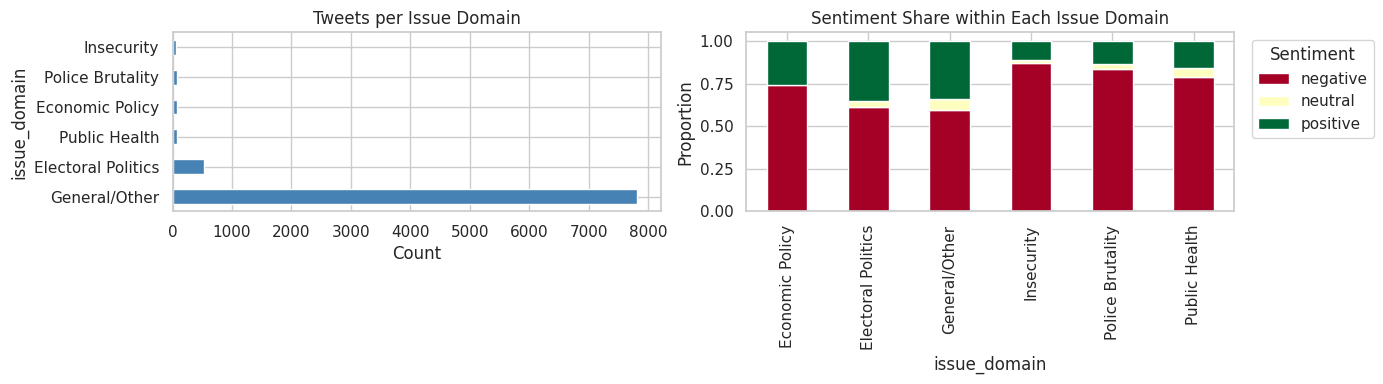

In [9]:

ISSUE_KEYWORDS = {
    "Electoral Politics": [
        "election", "elections", "vote", "voting", "inec", "ballot", "tinubu",
        "atiku", "peter obi", "obidient", "apc", "pdp", "labour party", "lp",
        "candidate", "governor", "president", "campaign", "rig", "rigging",
        "politician", "nigeriadecides",
    ],
    "Insecurity": [
        "insecurity", "bandit", "bandits", "kidnap", "kidnapping", "terrorist",
        "terrorism", "boko haram", "gunmen", "attack", "attacked", "herdsmen",
        "abduct", "abducted", "violence", "security forces", "killed",
        "massacre",
    ],
    "Economic Policy": [
        "fuel subsidy", "subsidy", "petrol", "fuel price", "naira", "inflation",
        "economy", "economic", "exchange rate", "forex", "cash crunch",
        "cashless", "poverty", "minimum wage", "tax", "cost of living",
        "naira redesign",
    ],
    "Police Brutality": [
        "police", "sars", "endsars", "brutality", "human rights",
        "extrajudicial", "police officer", "arrest", "arrested", "harass",
        "harassment", "police reform",
    ],
    "Public Health": [
        "health", "healthcare", "hospital", "doctor", "doctors", "nurse",
        "nurses strike", "nhis", "disease", "malaria", "covid", "clinic",
        "medical", "health sector", "resident doctors",
    ],
}


def tag_issue_domain(text):
    '''Score every domain by keyword-hit count and return the strongest match,
    rather than the first domain checked, so a tweet mentioning "governor"
    once and "hospital"/"doctor" twice is correctly tagged Public Health.'''
    t = str(text).lower()
    scores = {
        domain: sum(1 for kw in keywords if kw in t)
        for domain, keywords in ISSUE_KEYWORDS.items()
    }
    best_domain, best_score = max(scores.items(), key=lambda kv: kv[1])
    return best_domain if best_score > 0 else "General/Other"


df_raw["issue_domain"] = df_raw["text"].apply(tag_issue_domain)
print("Issue-domain distribution (keyword-matched):")
print(df_raw["issue_domain"].value_counts())

# Keep everything by default (General/Other included) so the SENTIMENT model
# still has enough training data; set False to strictly scope the corpus to
# your five domains only (expect a much smaller dataset).
KEEP_UNMATCHED_AS_GENERAL = True

if KEEP_UNMATCHED_AS_GENERAL:
    df = df_raw.copy()
else:
    df = df_raw[df_raw["issue_domain"] != "General/Other"].reset_index(drop=True)
    print(f"\nDropped unmatched rows; remaining: {len(df)}")

if (df["issue_domain"] != "General/Other").sum() < 300:
    print("\nWARNING: fewer than 300 tweets matched your five issue domains. "
          "Consider: (1) expanding ISSUE_KEYWORDS, (2) adding more NaijaSenti "
          "languages, or (3) supplementing with your own collection (Section 1B) "
          "for under-represented domains.")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df["issue_domain"].value_counts().plot(kind="barh", ax=ax[0], color="steelblue")
ax[0].set_title("Tweets per Issue Domain")
ax[0].set_xlabel("Count")

pd.crosstab(df["issue_domain"], df["label"], normalize="index").plot(
    kind="bar", stacked=True, ax=ax[1], colormap="RdYlGn"
)
ax[1].set_title("Sentiment Share within Each Issue Domain")
ax[1].set_ylabel("Proportion")
ax[1].legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/issue_domain_distribution.png", dpi=150)
plt.show()



## 2. Text Preprocessing Pipeline (Chapter 3.4)

Implements, in order: text cleaning (URLs/mentions/RT/HTML entities/emoji),
normalisation (lowercasing, repeated-character reduction, selective
punctuation removal, number handling), TweetTokenizer tokenisation
(preserves hashtags/emoticons), negation-aware stop-word removal, and
WordNet lemmatisation with a pass-through for Nigerian Pidgin/slang tokens.


In [10]:

NEGATION_WORDS = {"not", "no", "never", "none", "nobody", "nothing",
                   "neither", "nor", "nowhere", "without", "cannot", "cant", "can't"}

STOPWORDS = set(stopwords.words("english")) - NEGATION_WORDS

# A small seed lexicon of common Nigerian Pidgin / slang terms that should be
# preserved as-is (not passed through the English lemmatizer). Extend this
# list based on your annotators' guideline / corpus analysis.
PIDGIN_LEXICON = {
    "wahala", "abeg", "sha", "oyinbo", "japa", "sabi", "gist", "waka",
    "wetin", "dey", "una", "wahalaaaa", "naija", "omo", "shey", "kuku",
    "abi", "sef", "oga", "una", "yarn", "vex", "gbege", "jara", "chop",
}

tweet_tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=False)
lemmatizer = WordNetLemmatizer()

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
RT_RE = re.compile(r"\bRT\b", flags=re.IGNORECASE)
HTML_ENTITY_MAP = {"&amp;": "&", "&lt;": "<", "&gt;": ">", "&quot;": '"', "&#39;": "'"}
REPEAT_CHAR_RE = re.compile(r"(.)\1{2,}")
DECORATIVE_PUNCT_RE = re.compile(r"[\.\.\.\(\)\[\]\{\}\*_~`\"'\u2026]")
NUMBER_RE = re.compile(r"\b\d+\b")
SENTIMENT_PUNCT_KEEP = {"!", "?"}


def decode_html_entities(text):
    for k, v in HTML_ENTITY_MAP.items():
        text = text.replace(k, v)
    return text


def clean_text(text):
    '''Section 3.4.1 — Text Cleaning'''
    text = str(text)
    text = URL_RE.sub("", text)
    text = MENTION_RE.sub("", text)
    text = RT_RE.sub("", text)
    text = decode_html_entities(text)
    # Convert emojis to textual descriptions (carries sentiment, esp. sarcasm)
    text = emoji.demojize(text, delimiters=(" :", ": "))
    text = text.replace("_", " ")
    return text


def normalise_text(text):
    '''Section 3.4.2 — Normalisation'''
    text = text.lower()
    text = REPEAT_CHAR_RE.sub(r"\1\1", text)  # soooo -> soo, wahalaaaa -> wahalaa
    # strip decorative punctuation but keep sentiment-bearing ! and ?
    kept = []
    for ch in text:
        if ch in SENTIMENT_PUNCT_KEEP:
            kept.append(ch)
        elif ch in string.punctuation:
            continue
        else:
            kept.append(ch)
    text = "".join(kept)
    text = NUMBER_RE.sub(" <num> ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text):
    '''Section 3.4.3 — Tokenisation (TweetTokenizer keeps hashtags intact)'''
    return tweet_tokenizer.tokenize(text)


def remove_stopwords(tokens):
    '''Section 3.4.4 — Stop-word removal, negation-preserving'''
    return [t for t in tokens if (t not in STOPWORDS) and (len(t) > 1 or t in SENTIMENT_PUNCT_KEEP)]


def lemmatize_tokens(tokens):
    '''Section 3.4.5 — Lemmatisation, with Pidgin/slang pass-through'''
    out = []
    for t in tokens:
        if t.startswith("#") or t in PIDGIN_LEXICON or t in SENTIMENT_PUNCT_KEEP:
            out.append(t)
        else:
            out.append(lemmatizer.lemmatize(t))
    return out


def preprocess(text):
    '''Full pipeline: clean -> normalise -> tokenise -> stopword removal -> lemmatise'''
    text = clean_text(text)
    text = normalise_text(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    return " ".join(tokens)


# Quick sanity check
sample = "RT @user This #FuelSubsidyRemoval palava is NOT good at all!!! Wahalaaaa dey much 😂😂 https://t.co/xyz"
print("BEFORE:", sample)
print("AFTER: ", preprocess(sample))


BEFORE: RT @user This #FuelSubsidyRemoval palava is NOT good at all!!! Wahalaaaa dey much 😂😂 https://t.co/xyz
AFTER:  fuelsubsidyremoval palava not good ! ! wahalaa dey much face tear joy face tear joy


In [11]:

df["clean_text"] = df["text"].apply(preprocess)
df = df[df["clean_text"].str.strip().str.len() > 0].reset_index(drop=True)

# Lightly-cleaned text for the transformer fine-tuning section further down
# (Section 9). Transformers use subword tokenizers and attention over full
# context, so aggressive IR-style normalisation (lowercasing, stopword
# removal, lemmatisation) actually throws away useful signal for them —
# unlike the classical BoW/TF-IDF models, they should see text closer to
# its original form. We only strip the same noise (URLs/mentions/RT/HTML
# entities/emoji-to-text) via clean_text(), nothing more.
df["transformer_text"] = df["text"].apply(clean_text)

# Near-duplicate guard: real tweet corpora often contain many near-identical
# retweets/templated posts (same message, different @mention/URL/emoji) that
# look distinct in raw 'text' but collapse to the SAME string once cleaned.
# If left in, these can end up split across train/test and leak the answer,
# artificially inflating every model's score. We de-duplicate on clean_text
# (keeping the first occurrence) to prevent this.
before = len(df)
df = df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)
removed = before - len(df)
print(f"Removed {removed} near-duplicate tweets ({removed / before:.1%} of the corpus) "
      f"that collapsed to identical cleaned text. Remaining: {len(df)}")

df[["text", "clean_text", "transformer_text", "label"]].head(10)


Removed 8 near-duplicate tweets (0.1% of the corpus) that collapsed to identical cleaned text. Remaining: 8623


,text,clean_text,transformer_text,label
0,yeah ‍️the guy wants to trend dat was why e jo...,yeah ‍t guy want trend dat join nysc cant tre...,yeah ‍the guy wants to trend dat was why e joi...,negative
1,this life is so funny sef you will work hard a...,life funny sef work hard buy cloth shoe rain s...,this life is so funny sef you will work hard a...,negative
2,dis is unfair of urcompany goingtowks nw ive b...,dis unfair urcompany goingtowks nw ive bin com...,dis is unfair of urcompany goingtowks nw ive b...,negative
3,lil wayne don vex me im actually not excited a...,lil wayne vex im actually not excited,lil wayne don vex me im actually not excited a...,negative
4,dis is unfair of ur company going to wks nw iv...,dis unfair ur company going wks nw ive bin com...,dis is unfair of ur company going to wks nw iv...,negative
5,e be like u sef dey mad,like sef dey mad,e be like u sef dey mad,negative
6,sure parole with dem boys dey mainland like th...,sure parole dem boy dey mainland like no dem g...,sure parole with dem boys dey mainland like th...,negative
7,daddy mi o if a day is possible sef we go come...,daddy mi day possible sef go come dey chop chi...,daddy mi o if a day is possible sef we go come...,negative
8,today marks one small milestone in the beautif...,today mark one small milestone beautiful journ...,today marks one small milestone in the beautif...,negative
9,family dey call ooif no be billing na somethin...,family dey call ooif no billing na something d...,family dey call ooif no be billing na somethin...,negative


## 3. Label Encoding & Train / Validation / Test Split (70/10/20, Stratified — Section 3.7.1)

In [13]:

le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

y_all = df["label_enc"].to_numpy()
all_idx = np.arange(len(df))

# We split by ROW INDEX (not by array values) so that the classical models
# (Sections 4-8, using 'clean_text') and the transformer fine-tune (Section
# 9, using the lightly-cleaned 'transformer_text') train and test on the
# EXACT SAME tweets. That makes the two approaches a fair, apples-to-apples
# comparison rather than accidentally evaluating on different held-out sets.
# 70% train, 30% temp -> split temp into 1/3 (=10% of total) val, 2/3 (=20% of total) test
idx_train, idx_temp = train_test_split(
    all_idx, test_size=0.30, stratify=y_all, random_state=RANDOM_STATE
)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=(2/3), stratify=y_all[idx_temp], random_state=RANDOM_STATE
)

def subset(col, idx):
    return df[col].to_numpy(dtype=object)[idx]

X_train = subset("clean_text", idx_train)
X_val = subset("clean_text", idx_val)
X_test = subset("clean_text", idx_test)
y_train, y_val, y_test = y_all[idx_train], y_all[idx_val], y_all[idx_test]

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
for name, arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = pd.Series(arr).value_counts(normalize=True).sort_index()
    print(name, dict(zip(le.classes_, counts.round(3))))


{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Train: 6036  Val: 862  Test: 1725
train {'negative': 0.605, 'neutral': 0.059, 'positive': 0.335}
val {'negative': 0.606, 'neutral': 0.059, 'positive': 0.335}
test {'negative': 0.605, 'neutral': 0.059, 'positive': 0.336}


## 4. Feature Extraction — BoW and TF-IDF (Section 3.5)

In [14]:

# Bag-of-Words: top 10,000 terms, stopwords already removed during preprocessing
bow_vectorizer = CountVectorizer(max_features=10000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)
X_test_bow = bow_vectorizer.transform(X_test)

# TF-IDF: unigrams + bigrams, top 10,000 terms
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("BoW train shape:  ", X_train_bow.shape)
print("TFIDF train shape:", X_train_tfidf.shape)

# Word + character n-gram TF-IDF. Nigerian Pidgin has no standard spelling
# ("wahala"/"wahalaa"/"wahalah", "dey"/"de"), so word-level features alone
# fragment the same idea across many rare tokens. Character n-grams (2-5,
# within word boundaries) let the model share statistical strength across
# those spelling variants. FeatureUnion keeps this as ONE vectoriser object
# with a single .transform(), so it exports/deploys exactly like the others.
tfidf_wc_vectorizer = FeatureUnion([
    ("word", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), max_features=30000)),
])
X_train_tfidf_wc = tfidf_wc_vectorizer.fit_transform(X_train)
X_val_tfidf_wc = tfidf_wc_vectorizer.transform(X_val)
X_test_tfidf_wc = tfidf_wc_vectorizer.transform(X_test)
print("Word+Char TFIDF train shape:", X_train_tfidf_wc.shape)


BoW train shape:   (6036, 10000)
TFIDF train shape: (6036, 10000)
Word+Char TFIDF train shape: (6036, 40000)



## 5. Class-Imbalance Handling — SMOTE (Applied Correctly, Inside Cross-Validation)

**A note on a bug in an earlier version of this notebook, and why the fix
matters:** the first version of this pipeline applied SMOTE to the *entire*
training set once, before handing it to `GridSearchCV`. That leaks
information across CV folds — synthetic points generated from a tweet can
end up in a different fold than the original tweet, so a fold's "held-out"
score gets inflated by near-duplicates of points the model already saw.
The symptom is exactly what you'd expect: inflated, misleading CV scores
that don't track real held-out performance (e.g. SVM/LR/RF scoring ~0.84
CV macro-F1 while barely reaching ~0.44 on the real test set, and CV even
*ranking the models backwards* relative to test performance).

**The fix:** SMOTE is now embedded inside an `imblearn` Pipeline together
with the classifier, and that whole pipeline — not just the raw features —
is what's passed to `GridSearchCV`. This makes SMOTE refit fresh on only
the 4 training folds each time, leaving the 5th (held-out) fold untouched
by oversampling, exactly as it should be. This is wired up directly in
Section 6 below; this cell just reports the raw imbalance for context.


In [15]:

train_class_counts = pd.Series(y_train).value_counts().sort_index()
train_class_names = dict(zip(range(len(le.classes_)), le.classes_))
print("Training-set class balance (before any resampling):")
for cls_idx, count in train_class_counts.items():
    print(f"  {train_class_names[cls_idx]:>10s}: {count:5d}  "
          f"({count / len(y_train):.1%})")
imbalance_ratio = train_class_counts.min() / train_class_counts.max()
print(f"\nMinority:majority ratio = {imbalance_ratio:.3f} "
      f"({'notably imbalanced' if imbalance_ratio < 0.5 else 'roughly balanced'})")


Training-set class balance (before any resampling):
    negative:  3654  (60.5%)
     neutral:   357  (5.9%)
    positive:  2025  (33.5%)

Minority:majority ratio = 0.098 (notably imbalanced)


## 6. Model Training with 5-Fold Grid Search CV (Sections 3.6 & 3.7.2)

In [16]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# A conservative, fold-safe k_neighbors for SMOTE: since SMOTE now refits on
# only ~4/5 of X_train inside each CV fold, the smallest class there is even
# smaller than in the full training set. We size k_neighbors off that
# per-fold estimate so SMOTE doesn't crash on a rare class in a small fold.
min_class_count_full_train = pd.Series(y_train).value_counts().min()
per_fold_min_estimate = max(2, int(min_class_count_full_train * (cv.get_n_splits() - 1) / cv.get_n_splits()))
smote_k_neighbors = max(1, min(5, per_fold_min_estimate - 1))
print(f"Using SMOTE(k_neighbors={smote_k_neighbors}) based on estimated per-fold minority-class size.")

MODEL_GRID = {
    "Multinomial Naive Bayes": {
        "estimator": MultinomialNB(),
        # fit_prior=False = uniform class prior, a cheap way to stop NB from
        # defaulting to the majority class on imbalanced data.
        "param_grid": {"clf__alpha": [0.1, 0.3, 0.5, 1.0], "clf__fit_prior": [True, False]},
        "feature": "bow",   # MNB expects non-negative counts -> pair with BoW
    },
    "Linear SVM": {
        "estimator": LinearSVC(random_state=RANDOM_STATE, max_iter=5000),
        "param_grid": {"clf__C": [0.03, 0.1, 0.3, 1, 3], "clf__class_weight": [None, "balanced"]},
        "feature": "tfidf_wc",
    },
    "Logistic Regression": {
        "estimator": LogisticRegression(solver="lbfgs", penalty="l2",
                                         max_iter=2000,
                                         random_state=RANDOM_STATE),
        "param_grid": {"clf__C": [0.1, 0.3, 1, 3, 10, 30], "clf__class_weight": [None, "balanced"]},
        "feature": "tfidf_wc",
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        "param_grid": {"clf__max_depth": [20, None],
                       "clf__class_weight": [None, "balanced_subsample"]},
        "feature": "tfidf",
    },
}

# RAW (imbalanced) features — the imbalance strategy now lives inside each
# model's Pipeline and is chosen by cross-validation, never pre-applied here.
FEATURE_SETS = {
    "bow": {
        "train": (X_train_bow, y_train),
        "val": (X_val_bow, y_val),
        "test": (X_test_bow, y_test),
        "vectorizer": bow_vectorizer,
    },
    "tfidf": {
        "train": (X_train_tfidf, y_train),
        "val": (X_val_tfidf, y_val),
        "test": (X_test_tfidf, y_test),
        "vectorizer": tfidf_vectorizer,
    },
    "tfidf_wc": {
        "train": (X_train_tfidf_wc, y_train),
        "val": (X_val_tfidf_wc, y_val),
        "test": (X_test_tfidf_wc, y_test),
        "vectorizer": tfidf_wc_vectorizer,
    },
}

fitted_models = {}
smote_step = SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k_neighbors)

for name, cfg in MODEL_GRID.items():
    feat = cfg["feature"]
    X_tr, y_tr = FEATURE_SETS[feat]["train"]
    print(f"\n=== Grid search: {name} ({feat}) ===")

    pipe = ImbPipeline([
        ("smote", smote_step),
        ("clf", cfg["estimator"]),
    ])
    # The imbalance strategy is itself a hyper-parameter: SMOTE-in-fold, or
    # "passthrough" (no resampling; rely on class_weight / fit_prior instead).
    # Synthetic oversampling of sparse text vectors doesn't always beat plain
    # class weighting, so we let cross-validation decide rather than assume.
    param_grid = {"smote": [smote_step, "passthrough"], **cfg["param_grid"]}
    grid = GridSearchCV(
        pipe, param_grid,
        scoring="f1_macro", cv=cv, n_jobs=-1, verbose=0,
    )
    grid.fit(X_tr, y_tr)
    chosen_smote = "SMOTE" if grid.best_params_["smote"] != "passthrough" else "no resampling"
    print(f"Best params: { {k: v for k, v in grid.best_params_.items() if k != 'smote'} } "
          f"| imbalance strategy: {chosen_smote}")
    print(f"CV macro-F1 (resampling refit per fold): {grid.best_score_:.4f}")
    # grid.best_estimator_ is the full Pipeline. Its .predict() automatically
    # skips the sampler at inference time (imblearn Pipeline behavior), so
    # evaluating it on val/test below never resamples them.
    fitted_models[name] = {"model": grid.best_estimator_, "feature": feat, "cv_f1": grid.best_score_}


Using SMOTE(k_neighbors=5) based on estimated per-fold minority-class size.

=== Grid search: Multinomial Naive Bayes (bow) ===
Best params: {'clf__alpha': 1.0, 'clf__fit_prior': True} | imbalance strategy: SMOTE
CV macro-F1 (resampling refit per fold): 0.4772

=== Grid search: Linear SVM (tfidf_wc) ===
Best params: {'clf__C': 0.1, 'clf__class_weight': None} | imbalance strategy: SMOTE
CV macro-F1 (resampling refit per fold): 0.4921

=== Grid search: Logistic Regression (tfidf_wc) ===
Best params: {'clf__C': 0.3, 'clf__class_weight': None} | imbalance strategy: SMOTE
CV macro-F1 (resampling refit per fold): 0.4929

=== Grid search: Random Forest (tfidf) ===
Best params: {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 20} | imbalance strategy: no resampling
CV macro-F1 (resampling refit per fold): 0.4751


## 7. Evaluation — Validation (for model selection) and Held-Out Test (for reporting) (Section 3.8)


----- Multinomial Naive Bayes (BOW) -----
              precision    recall  f1-score   support

    negative       0.72      0.78      0.75      1044
     neutral       0.20      0.15      0.17       102
    positive       0.57      0.51      0.54       579

    accuracy                           0.65      1725
   macro avg       0.50      0.48      0.48      1725
weighted avg       0.64      0.65      0.64      1725


----- Linear SVM (TFIDF_WC) -----
              precision    recall  f1-score   support

    negative       0.75      0.72      0.73      1044
     neutral       0.24      0.35      0.29       102
    positive       0.56      0.56      0.56       579

    accuracy                           0.64      1725
   macro avg       0.52      0.54      0.53      1725
weighted avg       0.66      0.64      0.65      1725


----- Logistic Regression (TFIDF_WC) -----
              precision    recall  f1-score   support

    negative       0.75      0.71      0.73      1044
     ne

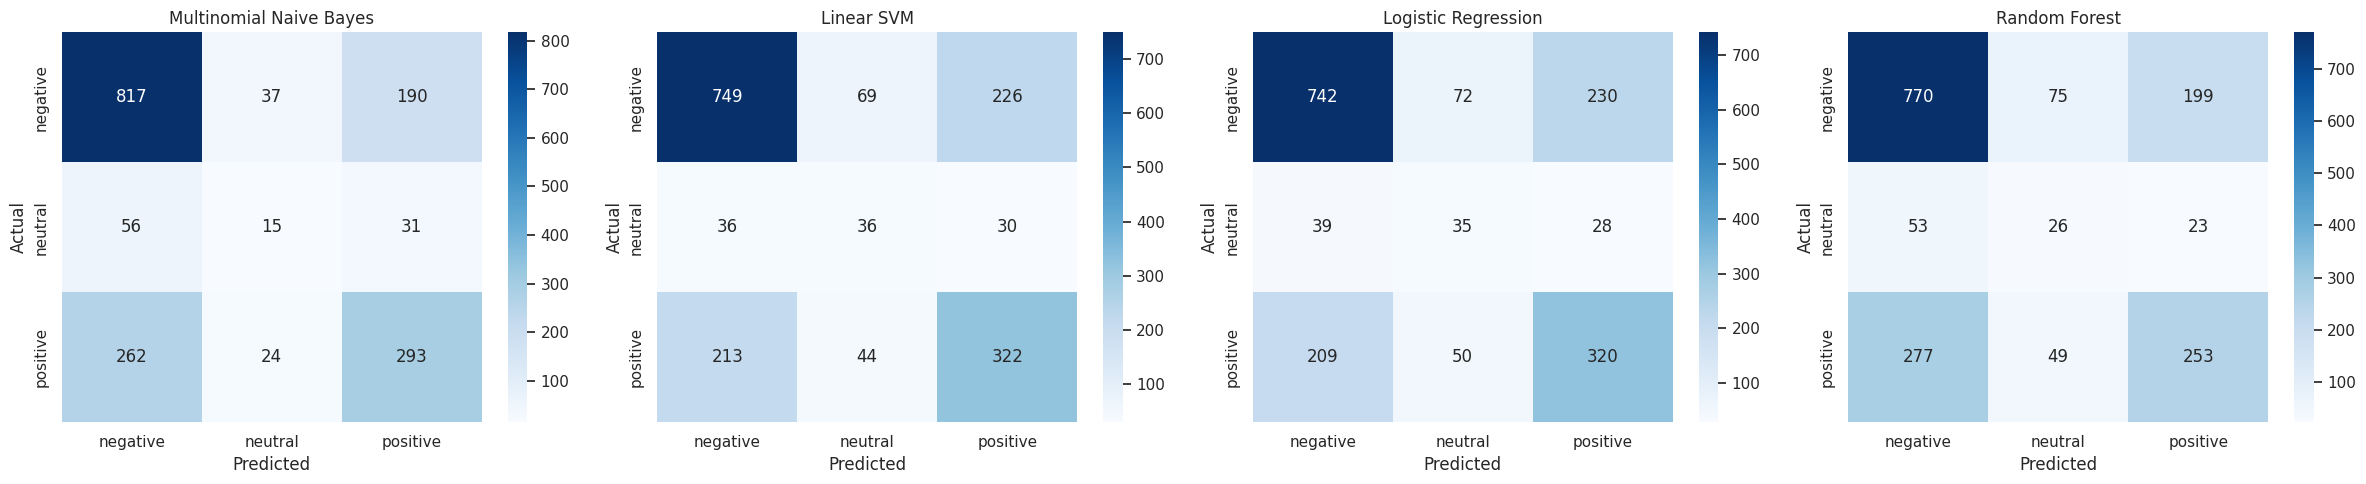

,Model,Features,CV Macro-F1,Val F1 (macro),Test Accuracy,Test Precision (macro),Test Recall (macro),Test F1 (macro),Test F1 (weighted),Test AUC-ROC (OvR macro)
0,Linear SVM,TFIDF_WC,0.492065,0.464446,0.641739,0.516402,0.542168,0.525686,0.647774,0.718542
1,Logistic Regression,TFIDF_WC,0.492865,0.464193,0.635942,0.508686,0.535514,0.517674,0.643213,0.720785
2,Multinomial Naive Bayes,BOW,0.477241,0.454068,0.652174,0.495744,0.478557,0.484855,0.643766,0.723700
3,Random Forest,TFIDF,0.475109,0.449711,0.608116,0.468655,0.476470,0.468236,0.608058,0.669063


In [17]:

def get_scores(model, X):
    '''Return probability-like scores for AUC-ROC even for LinearSVC (no predict_proba).'''
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        # softmax-normalise decision scores into pseudo-probabilities
        exp = np.exp(scores - scores.max(axis=1, keepdims=True))
        return exp / exp.sum(axis=1, keepdims=True)
    raise ValueError("Model has neither predict_proba nor decision_function")


results = []
class_names = le.classes_
n_classes = len(class_names)

fig_cm, axes_cm = plt.subplots(1, len(fitted_models), figsize=(6 * len(fitted_models), 5))
if len(fitted_models) == 1:
    axes_cm = [axes_cm]

for ax, (name, info) in zip(axes_cm, fitted_models.items()):
    model, feat = info["model"], info["feature"]
    X_te, y_te = FEATURE_SETS[feat]["test"]

    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_te, y_pred, average="macro", zero_division=0)
    _, _, f1_weighted, _ = precision_recall_fscore_support(y_te, y_pred, average="weighted", zero_division=0)

    # Validation macro-F1 is what we use to PICK the winning model (below),
    # so the test set stays untouched for honest final reporting.
    X_va, y_va = FEATURE_SETS[feat]["val"]
    val_f1 = f1_score(y_va, model.predict(X_va), average="macro", zero_division=0)

    y_score = get_scores(model, X_te)
    y_test_bin = label_binarize(y_te, classes=list(range(n_classes)))
    try:
        auc_macro = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
    except Exception:
        auc_macro = np.nan

    results.append({
        "Model": name, "Features": feat.upper(), "CV Macro-F1": info["cv_f1"],
        "Val F1 (macro)": val_f1,
        "Test Accuracy": acc, "Test Precision (macro)": precision,
        "Test Recall (macro)": recall, "Test F1 (macro)": f1,
        "Test F1 (weighted)": f1_weighted, "Test AUC-ROC (OvR macro)": auc_macro,
    })

    print(f"\n----- {name} ({feat.upper()}) -----")
    print(classification_report(y_te, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names,
                yticklabels=class_names, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrices.png", dpi=150)
plt.show()

# Rank by VALIDATION macro-F1 (model selection), not by test score.
results_df = pd.DataFrame(results).sort_values("Val F1 (macro)", ascending=False).reset_index(drop=True)
results_df


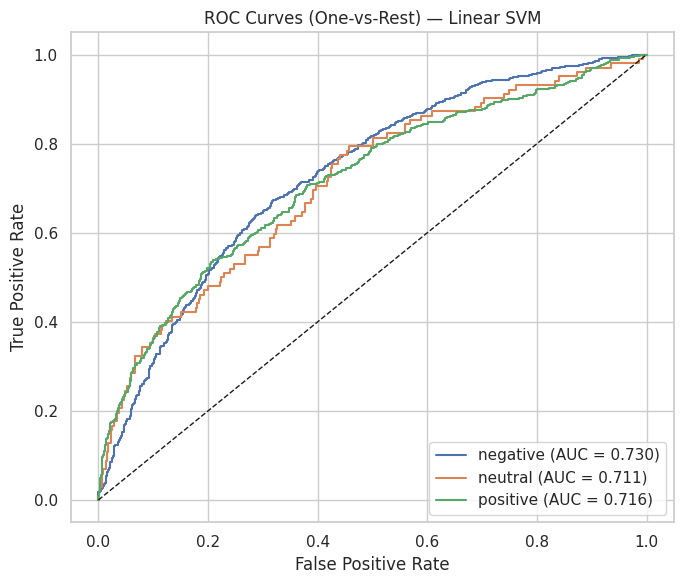

In [18]:

# ROC curves (one-vs-rest) for the best model
best_row = results_df.iloc[0]
best_name = best_row["Model"]
best_info = fitted_models[best_name]
X_te, y_te = FEATURE_SETS[best_info["feature"]]["test"]
y_score = get_scores(best_info["model"], X_te)
y_test_bin = label_binarize(y_te, classes=list(range(n_classes)))

plt.figure(figsize=(7, 6))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves (One-vs-Rest) — {best_name}")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curves_best_model.png", dpi=150)
plt.show()


## 8. Model Comparison

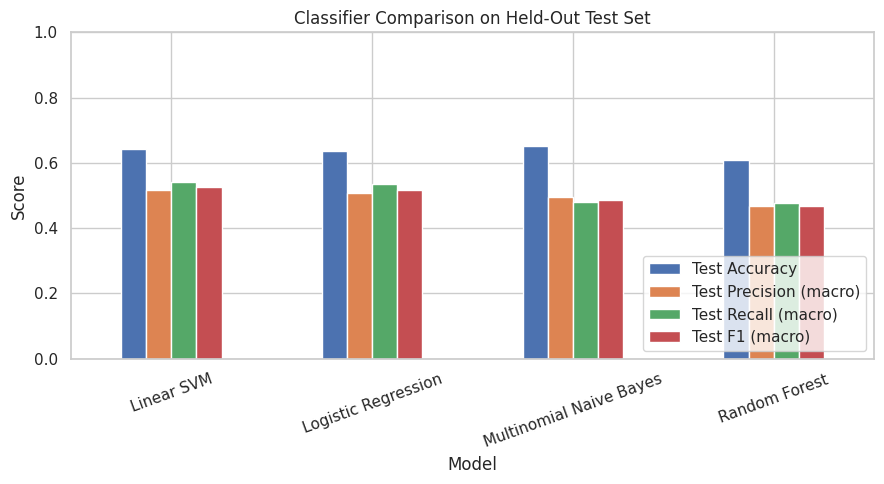


Best classical model (selected on validation macro-F1): Linear SVM  (val F1 = 0.4644, test macro-F1 = 0.5257, test weighted-F1 = 0.6478, features = TFIDF_WC)


In [19]:

plt.figure(figsize=(9, 5))
plot_df = results_df.set_index("Model")[["Test Accuracy", "Test Precision (macro)",
                                          "Test Recall (macro)", "Test F1 (macro)"]]
plot_df.plot(kind="bar", ax=plt.gca())
plt.ylabel("Score")
plt.title("Classifier Comparison on Held-Out Test Set")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison.png", dpi=150)
plt.show()

print(f"\nBest classical model (selected on validation macro-F1): {best_name}  "
      f"(val F1 = {best_row['Val F1 (macro)']:.4f}, test macro-F1 = {best_row['Test F1 (macro)']:.4f}, "
      f"test weighted-F1 = {best_row['Test F1 (weighted)']:.4f}, features = {best_row['Features']})")

if data_is_synthetic:
    print("\n" + "!" * 78)
    print("!! These scores were computed on SYNTHETIC/fallback data (see Section 1A).")
    print("!! They are not meaningful research results — re-run with real NaijaSenti")
    print("!! data (enable Internet in Notebook Settings) before reporting anything.")
    print("!" * 78)
elif results_df["Test F1 (macro)"].max() > 0.98:
    print("\nNote: a near-perfect macro-F1 (>0.98) on real data is unusually high for "
          "this task — double-check for residual leakage (e.g. duplicate/near-duplicate "
          "tweets across train/test) before trusting this number.")



## 9. Fine-Tuning a Transformer — Closing the Gap to Published Results

Classical bag-of-words models have a ceiling on informal, code-mixed text:
they can't tell that "e no bad" and "e bad" differ, or that a misspelt
Pidgin word is a cousin of a known one. The published NaijaSenti and
AfriSenti work reports its strongest results from **fine-tuned pretrained
transformers** (e.g. AfriBERTa reported above 70% F1 across the Nigerian
languages), so this section fine-tunes Africa-centric encoders on **the exact
same train/val/test rows** as the classical models above — a fair,
like-for-like comparison.

What's different from the classical pipeline, and why:

- **Lightly-cleaned text** (`transformer_text`): only URLs/mentions/RT/HTML
  noise removed. Case, punctuation, stopwords and negations are kept —
  transformers use them.
- **Class-weighted loss**: rare classes (neutral) cost more when missed,
  which directly targets macro-F1.
- **Model selection on validation macro-F1**: the best epoch is restored
  automatically; the test set is touched exactly once, for final reporting.

**Requires a GPU** (Notebook Settings → Accelerator → GPU T4 x2 or P100).
Without one this section skips itself cleanly and the rest of the notebook
is unaffected. Expect roughly 5–15 minutes per model on a T4.

*Comparability caveat for your write-up:* published numbers use the official
NaijaSenti splits and (often) weighted F1 across all four languages; here we
re-split the pooled Pidgin data ourselves and de-duplicate near-identical
tweets, so results are indicative rather than a strict leaderboard match.
Also note that `Davlan/naija-twitter-sentiment-afriberta-large` (the
authors' released checkpoint) was already trained on NaijaSenti's official
training data, so evaluating it on our re-shuffled test split would leak — we
deliberately fine-tune from the *pretrained* checkpoints instead.



Fine-tuning Davlan/afro-xlmr-base


config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/398 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


----- Fine-tuned castorini/afriberta_large -----
              precision    recall  f1-score   support

    negative       0.78      0.75      0.76      1044
     neutral       0.25      0.32      0.28       102
    positive       0.58      0.59      0.59       579

    accuracy                           0.67      1725
   macro avg       0.54      0.56      0.54      1725
weighted avg       0.68      0.67      0.68      1725



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

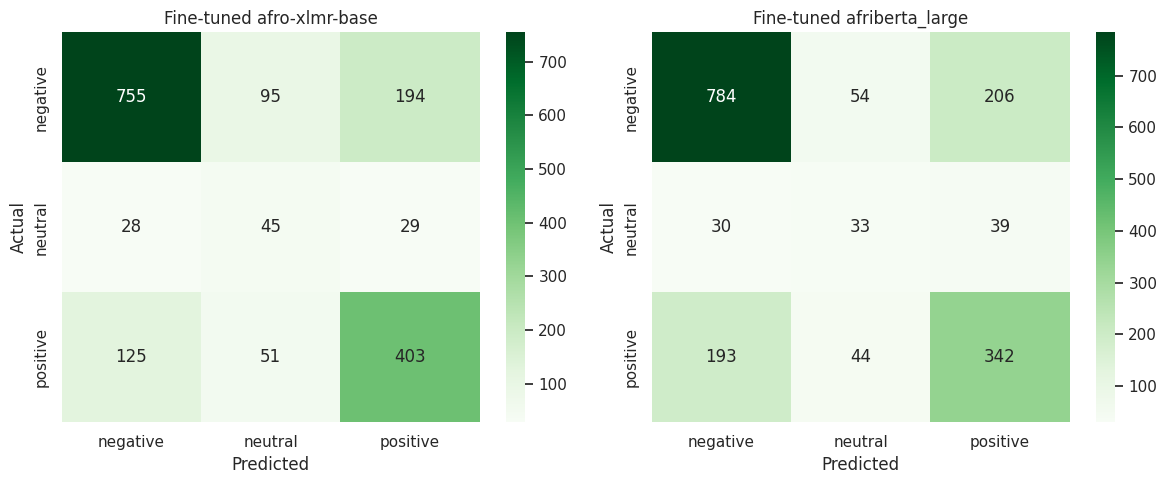

,Model,Features,CV Macro-F1,Val F1 (macro),Test Accuracy,Test Precision (macro),Test Recall (macro),Test F1 (macro),Test F1 (weighted),Test AUC-ROC (OvR macro)
0,Fine-tuned afro-xlmr-base,TRANSFORMER,NaN,0.564964,0.697391,0.570290,0.620128,0.583204,0.710849,0.769882
1,Fine-tuned afriberta_large,TRANSFORMER,NaN,0.519223,0.671884,0.537694,0.555054,0.544796,0.676342,0.732925
2,Linear SVM,TFIDF_WC,0.492065,0.464446,0.641739,0.516402,0.542168,0.525686,0.647774,0.718542
3,Logistic Regression,TFIDF_WC,0.492865,0.464193,0.635942,0.508686,0.535514,0.517674,0.643213,0.720785
4,Multinomial Naive Bayes,BOW,0.477241,0.454068,0.652174,0.495744,0.478557,0.484855,0.643766,0.723700
5,Random Forest,TFIDF,0.475109,0.449711,0.608116,0.468655,0.476470,0.468236,0.608058,0.669063


In [20]:
# ----- EDIT THESE ----------------------------------------------------
RUN_TRANSFORMER = True          # needs a GPU (Notebook Settings > Accelerator > GPU T4/P100)
ALLOW_CPU_TRANSFORMER = False   # CPU fine-tuning is impractically slow; leave False

# Africa-centric pretrained encoders that cover Nigerian Pidgin / Nigerian languages:
#   Davlan/afro-xlmr-base      (AfroXLMR, ~270M params)
#   castorini/afriberta_large  (AfriBERTa-large, ~126M params; the model family behind
#                               the NaijaSenti paper's >70% F1 result)
#   Davlan/afro-xlmr-mini      (smaller/faster; use if you hit GPU-memory or time limits)
TRANSFORMER_MODELS = ["Davlan/afro-xlmr-base", "castorini/afriberta_large"]
TRANSFORMER_EPOCHS = 5
TRANSFORMER_LR = 3e-5
TRANSFORMER_BATCH_SIZE = 32
TRANSFORMER_MAX_LEN = 128       # tweets are short; 128 subword tokens is ample
# ----------------------------------------------------------------------

import gc
import shutil
import dataclasses

transformer_rows = []       # one results row per fine-tuned model
transformer_artifacts = {}  # model name -> {"path": ..., "val_f1": ...}

try:
    import torch
    has_gpu = torch.cuda.is_available()
except Exception:
    torch, has_gpu = None, False

if RUN_TRANSFORMER and torch is None:
    print("PyTorch is not available in this environment — skipping transformer fine-tuning.")
    RUN_TRANSFORMER = False
elif RUN_TRANSFORMER and not (has_gpu or ALLOW_CPU_TRANSFORMER):
    print("=" * 78)
    print("No GPU detected — skipping transformer fine-tuning (it would take hours on CPU).")
    print("To run it: Notebook Settings > Accelerator > GPU T4 x2 (or P100), then re-run.")
    print("=" * 78)
    RUN_TRANSFORMER = False

if RUN_TRANSFORMER:
    pip_install(["transformers", "accelerate", "sentencepiece"])


def finetune_and_evaluate(model_name):
    '''Fine-tune one pretrained encoder on the SAME train/val/test rows the
    classical models used, and return a results row + saved-model path.'''
    from datasets import Dataset
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              TrainingArguments, Trainer, DataCollatorWithPadding)

    safe_name = model_name.replace("/", "__")
    print(f"\n{'=' * 78}\nFine-tuning {model_name}\n{'=' * 78}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.model_max_length = 512  # sentencepiece-imported tokenizers (e.g. AfriBERTa) don't set this
    id2label = {i: str(c) for i, c in enumerate(le.classes_)}
    label2id = {v: k for k, v in id2label.items()}
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=n_classes, id2label=id2label, label2id=label2id
    )

    def make_ds(texts, labels):
        ds = Dataset.from_dict({"text": [str(t) for t in texts], "label": [int(l) for l in labels]})
        return ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=TRANSFORMER_MAX_LEN),
                      batched=True)

    # SAME rows as the classical models (idx_* from Section 3), but lightly-cleaned text
    ds_train = make_ds(subset("transformer_text", idx_train), y_train)
    ds_val = make_ds(subset("transformer_text", idx_val), y_val)
    ds_test = make_ds(subset("transformer_text", idx_test), y_test)

    # Class-weighted cross-entropy: rare classes (neutral) cost more when missed.
    counts = np.bincount(y_train, minlength=n_classes).astype(float)
    class_weights = torch.tensor(counts.sum() / (n_classes * np.maximum(counts, 1)), dtype=torch.float)
    print("Class weights used in the loss:", dict(zip(le.classes_, class_weights.numpy().round(2))))

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs["labels"]
            outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
            logits = outputs.logits
            loss = torch.nn.functional.cross_entropy(logits, labels, weight=class_weights.to(logits.device))
            return (loss, outputs) if return_outputs else loss

    def compute_metrics(eval_pred):
        logits, y_true = eval_pred
        if isinstance(logits, tuple):
            logits = logits[0]
        y_hat = np.argmax(logits, axis=-1)
        p, r, f, _ = precision_recall_fscore_support(y_true, y_hat, average="macro", zero_division=0)
        return {"accuracy": accuracy_score(y_true, y_hat), "macro_f1": f,
                "macro_precision": p, "macro_recall": r}

    # TrainingArguments has renamed a few options across transformers releases
    # (evaluation_strategy -> eval_strategy, warmup_ratio changes), so build the
    # kwargs from the fields this installed version actually supports.
    ta_fields = {f.name for f in dataclasses.fields(TrainingArguments)}
    ta_kwargs = dict(
        output_dir=f"/tmp/ckpt_{safe_name}",
        num_train_epochs=TRANSFORMER_EPOCHS,
        per_device_train_batch_size=TRANSFORMER_BATCH_SIZE,
        per_device_eval_batch_size=64,
        learning_rate=TRANSFORMER_LR,
        weight_decay=0.01,
        save_strategy="epoch",
        load_best_model_at_end=True,       # keep the epoch with the best VALIDATION macro-F1
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=1,
        logging_steps=50,
        report_to="none",
        seed=RANDOM_STATE,
        fp16=bool(has_gpu),
    )
    ta_kwargs["eval_strategy" if "eval_strategy" in ta_fields else "evaluation_strategy"] = "epoch"
    if "warmup_ratio" in ta_fields:
        ta_kwargs["warmup_ratio"] = 0.1
    args = TrainingArguments(**{k: v for k, v in ta_kwargs.items() if k in ta_fields})

    trainer = WeightedTrainer(
        model=model, args=args,
        train_dataset=ds_train, eval_dataset=ds_val,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    trainer.train()

    val_metrics = trainer.evaluate(ds_val)          # best epoch (loaded at end), validation set
    pred = trainer.predict(ds_test)                  # test set — touched exactly once
    logits = pred.predictions[0] if isinstance(pred.predictions, tuple) else pred.predictions
    y_pred = logits.argmax(axis=-1)
    exp = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = exp / exp.sum(axis=1, keepdims=True)

    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    _, _, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
    try:
        auc_macro = roc_auc_score(label_binarize(y_test, classes=list(range(n_classes))),
                                  probs, average="macro", multi_class="ovr")
    except Exception:
        auc_macro = np.nan

    print(f"\n----- Fine-tuned {model_name} -----")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    save_dir = f"/tmp/final_{safe_name}"
    trainer.save_model(save_dir)
    tokenizer.save_pretrained(save_dir)

    row = {
        "Model": f"Fine-tuned {model_name.split('/')[-1]}", "Features": "TRANSFORMER",
        "CV Macro-F1": np.nan, "Val F1 (macro)": val_metrics["eval_macro_f1"],
        "Test Accuracy": acc, "Test Precision (macro)": p, "Test Recall (macro)": r,
        "Test F1 (macro)": f1, "Test F1 (weighted)": f1_w, "Test AUC-ROC (OvR macro)": auc_macro,
    }
    cm = confusion_matrix(y_test, y_pred)

    del trainer, model
    gc.collect()
    if has_gpu:
        torch.cuda.empty_cache()
    return row, save_dir, cm


transformer_cms = {}
if RUN_TRANSFORMER:
    for m_name in TRANSFORMER_MODELS:
        try:
            row, save_dir, cm = finetune_and_evaluate(m_name)
            transformer_rows.append(row)
            transformer_artifacts[row["Model"]] = {"path": save_dir, "val_f1": row["Val F1 (macro)"]}
            transformer_cms[row["Model"]] = cm
        except Exception as e:
            print(f"\nFine-tuning {m_name} failed and was skipped: {type(e).__name__}: {e}")

if transformer_rows:
    fig, axes = plt.subplots(1, len(transformer_cms), figsize=(6 * len(transformer_cms), 5))
    axes = np.atleast_1d(axes)
    for ax, (nm, cm) in zip(axes, transformer_cms.items()):
        sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=class_names,
                    yticklabels=class_names, ax=ax)
        ax.set_title(nm)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrices_transformers.png", dpi=150)
    plt.show()

# Combined table: classical + transformer, ranked by VALIDATION macro-F1
results_all_df = (pd.concat([results_df, pd.DataFrame(transformer_rows)], ignore_index=True)
                  .sort_values("Val F1 (macro)", ascending=False).reset_index(drop=True))
results_all_df


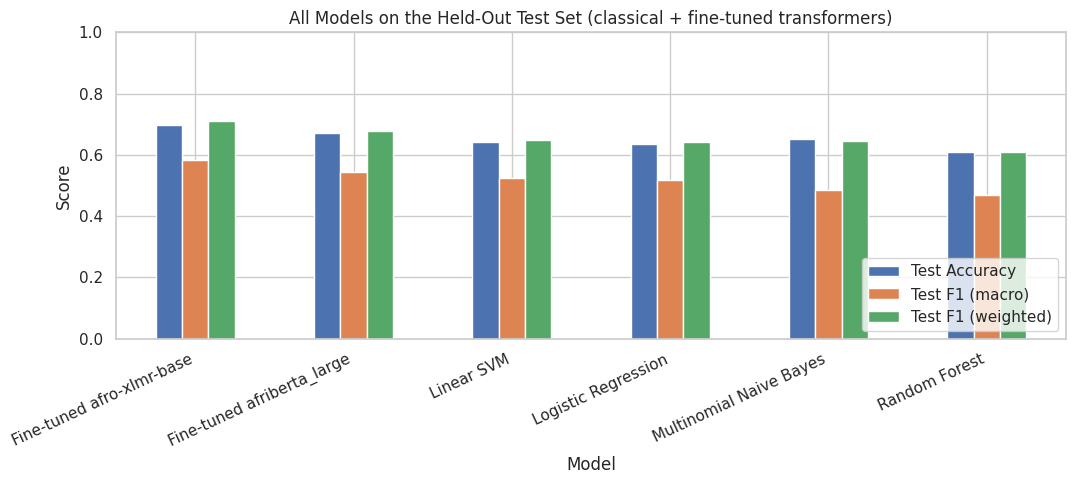

Best overall model (selected on validation macro-F1): Fine-tuned afro-xlmr-base
  test macro-F1 = 0.5832 | test weighted-F1 = 0.7108 | test accuracy = 0.6974


In [21]:

plot_cols = ["Test Accuracy", "Test F1 (macro)", "Test F1 (weighted)"]
ax = results_all_df.set_index("Model")[plot_cols].plot(kind="bar", figsize=(11, 5))
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("All Models on the Held-Out Test Set (classical + fine-tuned transformers)")
plt.xticks(rotation=25, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison_all.png", dpi=150)
plt.show()

top = results_all_df.iloc[0]
print(f"Best overall model (selected on validation macro-F1): {top['Model']}")
print(f"  test macro-F1 = {top['Test F1 (macro)']:.4f} | test weighted-F1 = {top['Test F1 (weighted)']:.4f} "
      f"| test accuracy = {top['Test Accuracy']:.4f}")



## 10. Export Artifacts for Deployment (Streamlit)

Always saves the best **classical** model + vectoriser + label encoder (light,
fast, ideal for a free Streamlit deployment). If transformer fine-tuning ran,
the best transformer is also saved to `transformer_model/` and the Streamlit
app will offer it as a second option. Download everything from the
notebook's **Output** panel into the Streamlit app's `model/` folder.


In [22]:

import shutil

best_model_obj = fitted_models[best_name]["model"]
best_vectorizer_obj = FEATURE_SETS[fitted_models[best_name]["feature"]]["vectorizer"]

joblib.dump(best_model_obj, f"{OUTPUT_DIR}/sentiment_model.pkl")
joblib.dump(best_vectorizer_obj, f"{OUTPUT_DIR}/vectorizer.pkl")
joblib.dump(le, f"{OUTPUT_DIR}/label_encoder.pkl")

# Best transformer (by validation macro-F1), if any was fine-tuned
best_tf_name, transformer_dir_name = None, None
if transformer_artifacts:
    best_tf_name = max(transformer_artifacts, key=lambda k: transformer_artifacts[k]["val_f1"])
    transformer_dir_name = "transformer_model"
    dst = f"{OUTPUT_DIR}/{transformer_dir_name}"
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(transformer_artifacts[best_tf_name]["path"], dst,
                    ignore=shutil.ignore_patterns("training_args.bin", "optimizer.pt",
                                                  "scheduler.pt", "rng_state.pth"))
    print(f"Saved best transformer ({best_tf_name}) to {dst}")

metrics_clean = results_all_df.astype(object).where(results_all_df.notna(), None)
metadata = {
    "best_model": best_name,                       # best CLASSICAL model (the joblib files)
    "feature_type": fitted_models[best_name]["feature"],
    "best_overall_model": results_all_df.iloc[0]["Model"],
    "transformer_model": best_tf_name,             # None if no transformer was trained
    "transformer_dir": transformer_dir_name,       # folder name under model/ in the Streamlit app
    "classes": le.classes_.tolist(),
    "metrics": metrics_clean.to_dict(orient="records"),
}
with open(f"{OUTPUT_DIR}/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=float)

print("Saved artifacts to", OUTPUT_DIR)
print(json.dumps({k: v for k, v in metadata.items() if k != "metrics"}, indent=2))


Saved best transformer (Fine-tuned afro-xlmr-base) to /kaggle/working/transformer_model
Saved artifacts to /kaggle/working
{
  "best_model": "Linear SVM",
  "feature_type": "tfidf_wc",
  "best_overall_model": "Fine-tuned afro-xlmr-base",
  "transformer_model": "Fine-tuned afro-xlmr-base",
  "transformer_dir": "transformer_model",
  "classes": [
    "negative",
    "neutral",
    "positive"
  ]
}


In [23]:

# Optional: quick manual test of the exported pipeline before deploying
def predict_sentiment(raw_text, model=best_model_obj, vectorizer=best_vectorizer_obj, encoder=le):
    cleaned = preprocess(raw_text)
    X_vec = vectorizer.transform([cleaned])
    pred = model.predict(X_vec)[0]
    label = encoder.inverse_transform([pred])[0]
    scores = get_scores(model, X_vec)[0]
    proba = dict(zip(encoder.classes_, np.round(scores, 4)))
    return label, proba

for t in [
    "This fuel subsidy removal is causing serious hardship for ordinary Nigerians #FuelSubsidyRemoval",
    "Big up to INEC for a smooth process today, well done!",
    "There will be a press briefing on the health sector reforms tomorrow.",
]:
    label, proba = predict_sentiment(t)
    print(f"TEXT: {t}\nPREDICTED: {label}  |  PROBA: {proba}\n")


TEXT: This fuel subsidy removal is causing serious hardship for ordinary Nigerians #FuelSubsidyRemoval
PREDICTED: negative  |  PROBA: {'negative': np.float64(0.7094), 'neutral': np.float64(0.1495), 'positive': np.float64(0.1411)}

TEXT: Big up to INEC for a smooth process today, well done!
PREDICTED: positive  |  PROBA: {'negative': np.float64(0.2186), 'neutral': np.float64(0.1694), 'positive': np.float64(0.612)}

TEXT: There will be a press briefing on the health sector reforms tomorrow.
PREDICTED: negative  |  PROBA: {'negative': np.float64(0.3982), 'neutral': np.float64(0.2821), 'positive': np.float64(0.3197)}

